# Question 3

### Library import

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

### EDA

In [70]:
df = pd.read_csv("Regression_Dataset.csv", index_col = 0)

In [71]:
df

,Marital,Job,Home,Income,Expenses,Assets,Debt,Loan_Term,Loan_Amount,Job_type_1,Job_type_2,Credit Score
Customer ID,,,,,,,,,,,,
364782,married,freelance,tenant,129000,73000,0,0,60,800,1,0,54
364783,single,fixed,tenant,131000,48000,0,0,60,1000,0,1,65
364784,married,freelance,owner,200000,90000,3000,0,36,2000,1,0,49
364785,single,fixed,tenant,182000,63000,2500,0,60,900,0,1,55
364786,single,fixed,tenant,107000,46000,0,0,36,310,0,1,75
...,...,...,...,...,...,...,...,...,...,...,...,...
369197,married,fixed,owner,100000,35000,5000,0,60,900,0,1,73
369198,married,freelance,owner,140000,45000,4300,0,60,2200,1,0,57
369199,married,fixed,owner,154000,35000,7000,1700,36,1400,0,1,78


In [72]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = df.select_dtypes(exclude="object").columns.tolist()

In [73]:
cat_cols

['Marital', 'Job', 'Home']

In [74]:
num_cols

['Income',
 'Expenses',
 'Assets',
 'Debt',
 'Loan_Term',
 'Loan_Amount',
 'Job_type_1',
 'Job_type_2',
 'Credit Score']

In [75]:
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())

Value counts for Marital:
Marital
married    3220
single     1200
Name: count, dtype: int64
Value counts for Job:
Job
fixed        2790
freelance    1184
parttime      446
Name: count, dtype: int64
Value counts for Home:
Home
tenant    2330
owner     2090
Name: count, dtype: int64


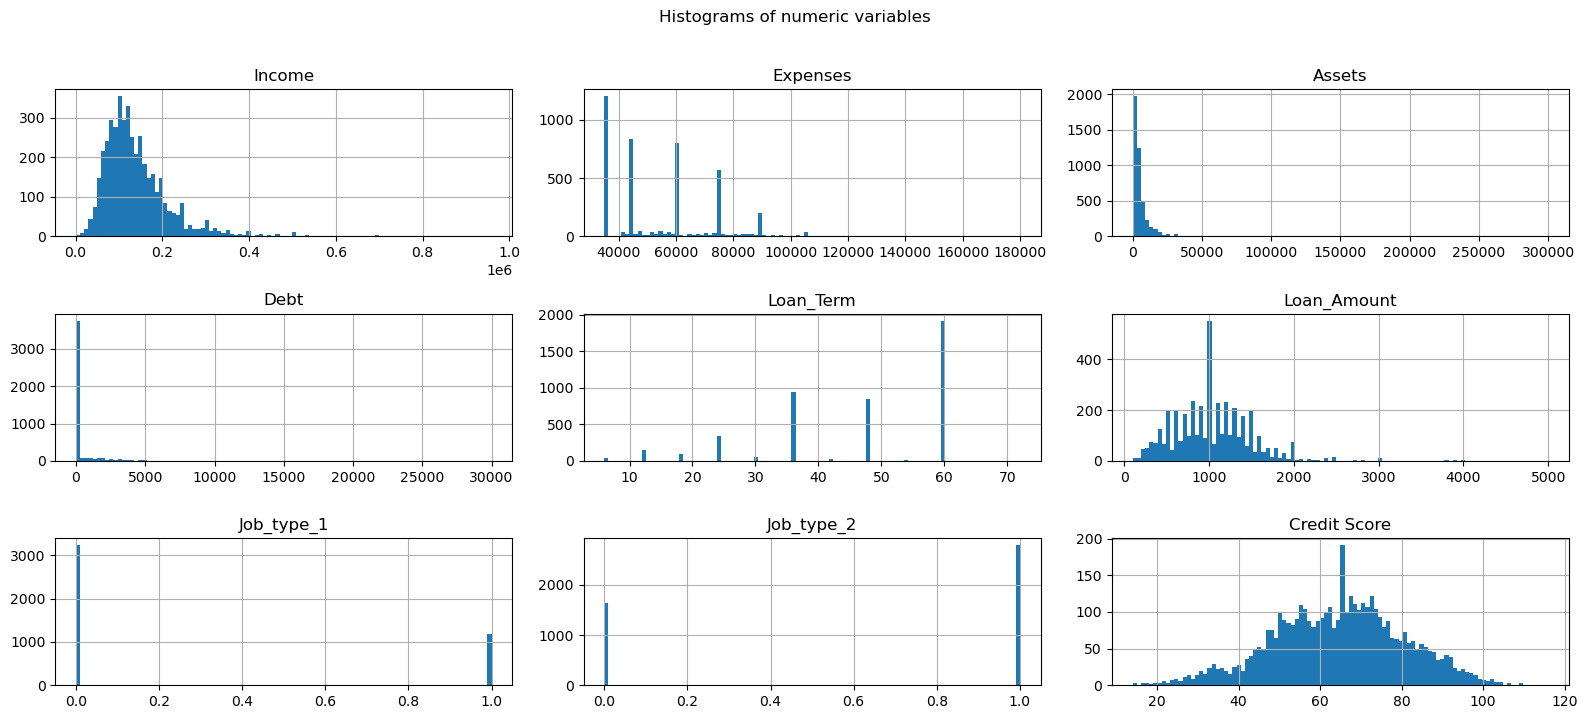

In [76]:
df.hist(figsize=(16, 7), bins=100)
plt.suptitle("Histograms of numeric variables", y=1.02)
plt.tight_layout()
plt.show()

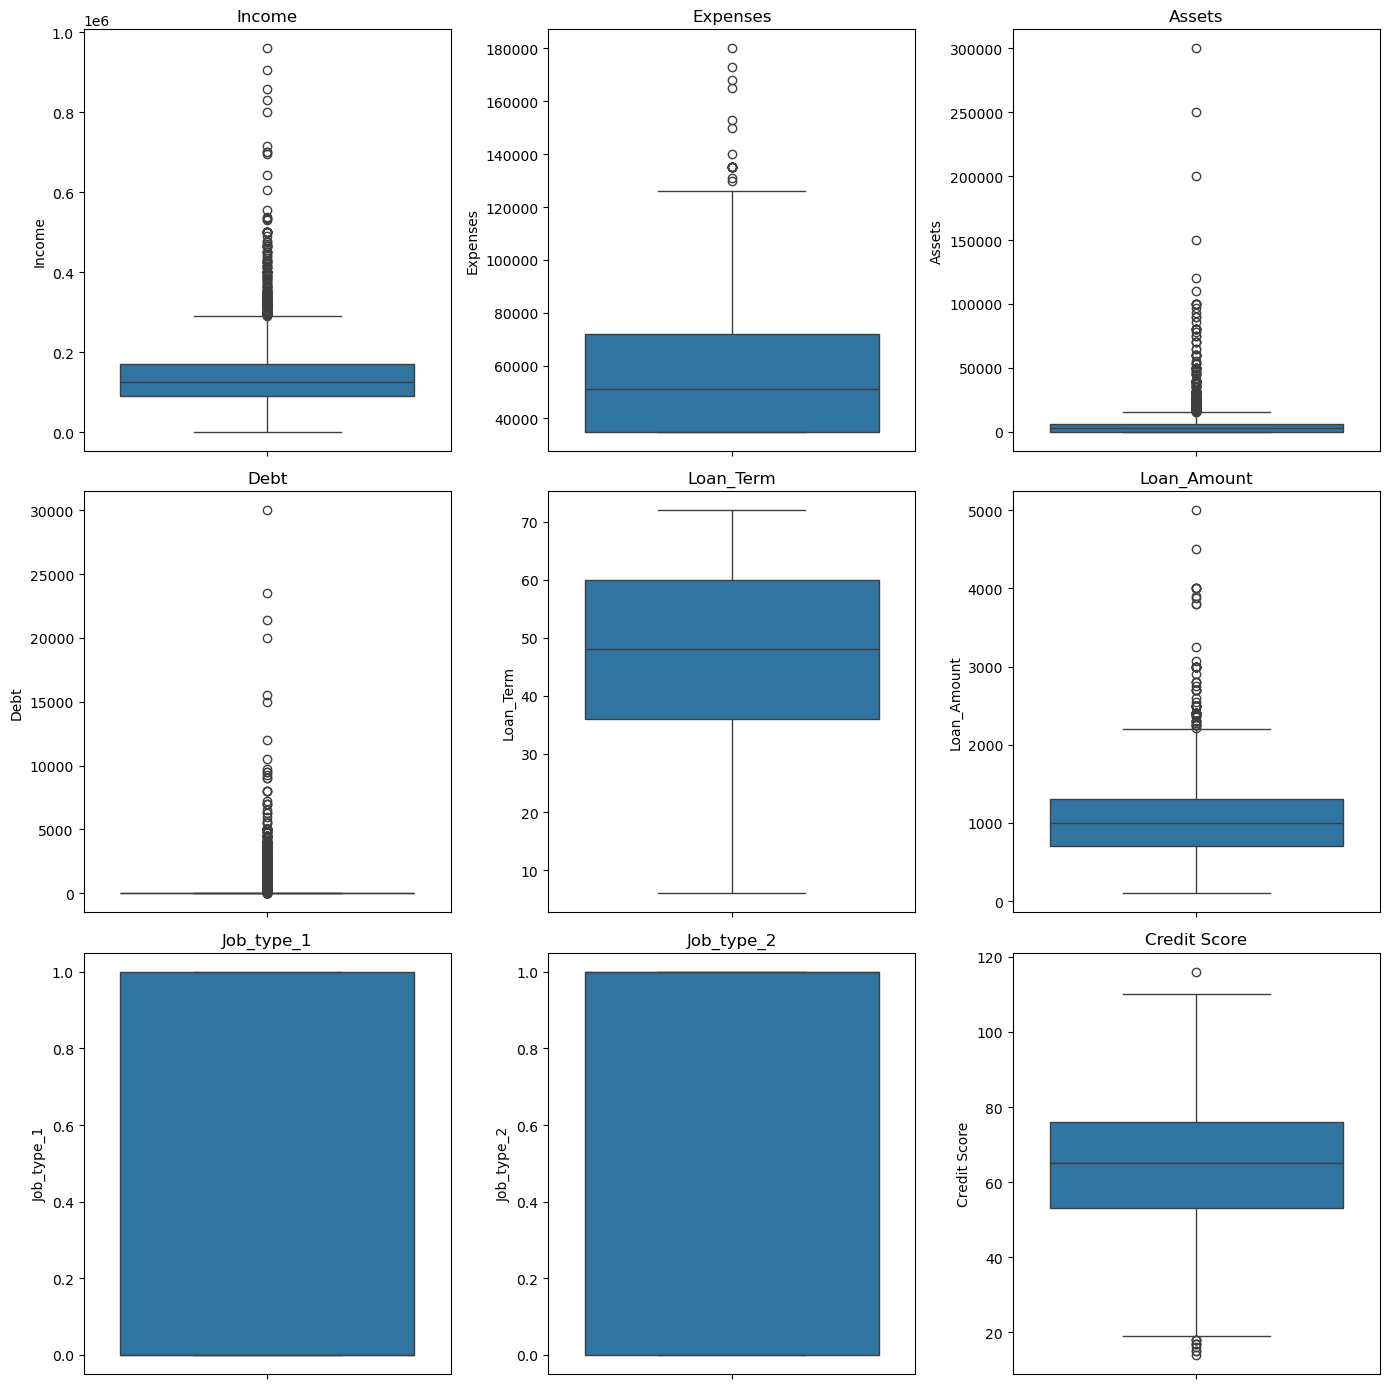

In [77]:
plt.figure(figsize=(14, 14))
for i, col in enumerate(df.select_dtypes(exclude='object').columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [78]:
corr = df.select_dtypes(exclude='object').corr()
corr

,Income,Expenses,Assets,Debt,Loan_Term,Loan_Amount,Job_type_1,Job_type_2,Credit Score
Income,1.000000,0.256748,0.219971,0.144233,-0.029932,0.191786,0.067298,0.022684,0.235327
Expenses,0.256748,1.000000,0.019521,0.014511,-0.001939,0.049625,0.067955,-0.004988,0.065238
Assets,0.219971,0.019521,1.000000,0.192079,-0.082929,0.144156,0.232405,-0.163836,0.221106
Debt,0.144233,0.014511,0.192079,1.000000,0.058369,0.050967,0.045166,-0.021315,0.027788
Loan_Term,-0.029932,-0.001939,-0.082929,0.058369,1.000000,0.430065,-0.142525,0.134344,-0.159871
Loan_Amount,0.191786,0.049625,0.144156,0.050967,0.430065,1.000000,0.089482,-0.042006,-0.211050
Job_type_1,0.067298,0.067955,0.232405,0.045166,-0.142525,0.089482,1.000000,-0.791371,-0.076076
Job_type_2,0.022684,-0.004988,-0.163836,-0.021315,0.134344,-0.042006,-0.791371,1.000000,0.290577
Credit Score,0.235327,0.065238,0.221106,0.027788,-0.159871,-0.211050,-0.076076,0.290577,1.000000


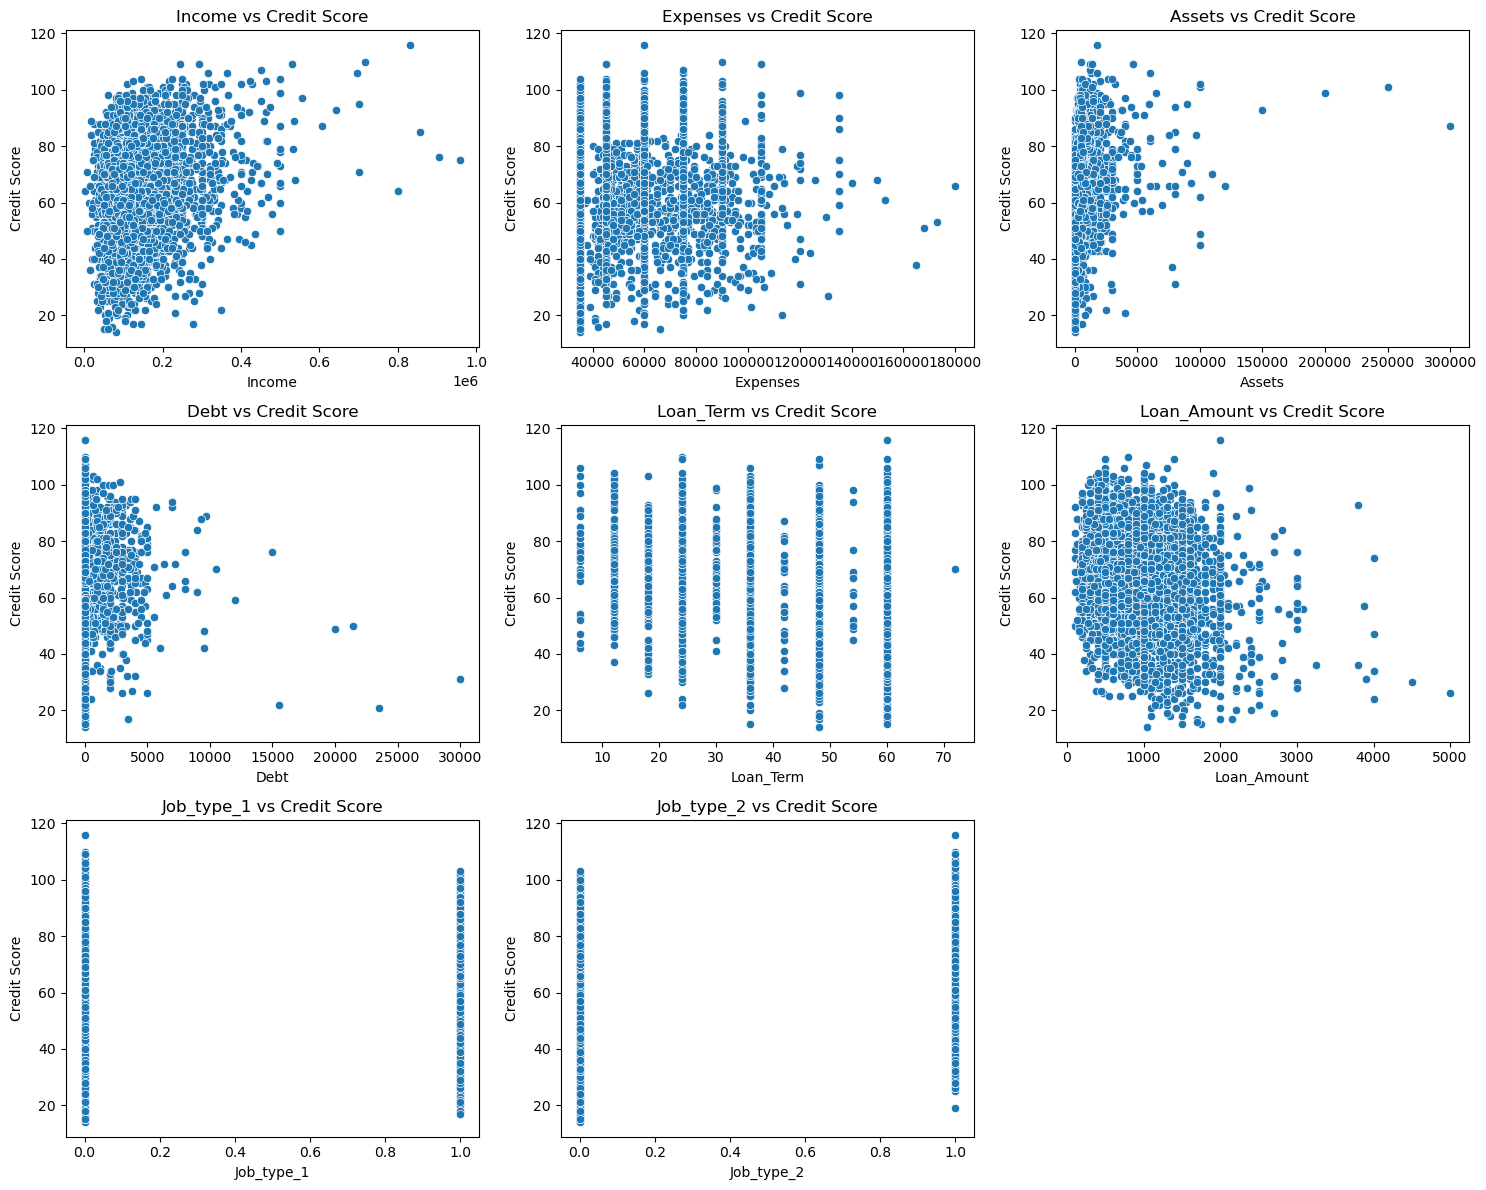

In [79]:
target = "Credit Score"
features_to_plot = [col for col in df.select_dtypes(exclude='object').columns if col != target]

plt.figure(figsize=(15, 12))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
plt.tight_layout()
plt.show()


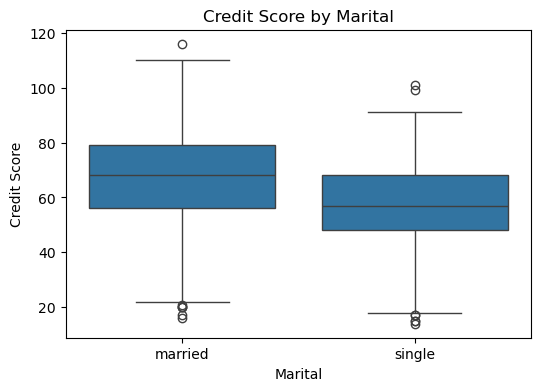

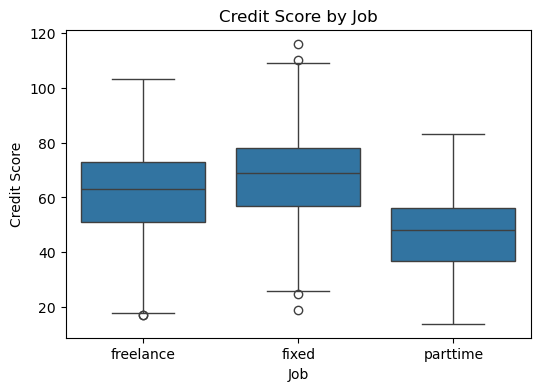

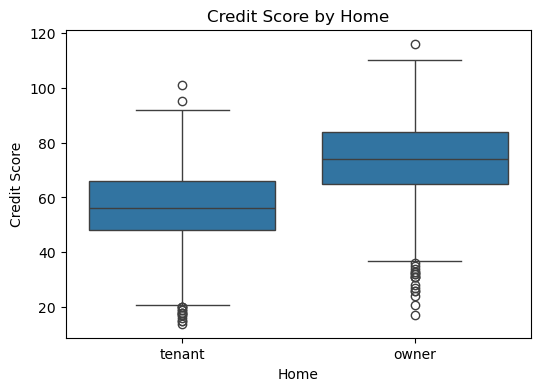

In [80]:
for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"{target} by {col}")
    plt.show()

In [81]:
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True) ## use drop_first = True to avoid multicol-y.  

In [82]:
df_model

,Income,Expenses,Assets,Debt,Loan_Term,Loan_Amount,Job_type_1,Job_type_2,Credit Score,Marital_single,Job_freelance,Job_parttime,Home_tenant
Customer ID,,,,,,,,,,,,,
364782,129000,73000,0,0,60,800,1,0,54,False,True,False,True
364783,131000,48000,0,0,60,1000,0,1,65,True,False,False,True
364784,200000,90000,3000,0,36,2000,1,0,49,False,True,False,False
364785,182000,63000,2500,0,60,900,0,1,55,True,False,False,True
364786,107000,46000,0,0,36,310,0,1,75,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369197,100000,35000,5000,0,60,900,0,1,73,False,False,False,False
369198,140000,45000,4300,0,60,2200,1,0,57,False,True,False,False
369199,154000,35000,7000,1700,36,1400,0,1,78,False,False,False,False


In [83]:
df_model = df_model.drop(columns=["Job_type_2"]) ## we already have binary job_type_1 col. 
df_model = df_model.drop(columns=["Job_type_1"]) #dropping Job type 1, ideal multi-y between job freelance and job type, probably job type 1 is freelance or not

In [84]:
df_model

,Income,Expenses,Assets,Debt,Loan_Term,Loan_Amount,Credit Score,Marital_single,Job_freelance,Job_parttime,Home_tenant
Customer ID,,,,,,,,,,,
364782,129000,73000,0,0,60,800,54,False,True,False,True
364783,131000,48000,0,0,60,1000,65,True,False,False,True
364784,200000,90000,3000,0,36,2000,49,False,True,False,False
364785,182000,63000,2500,0,60,900,55,True,False,False,True
364786,107000,46000,0,0,36,310,75,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
369197,100000,35000,5000,0,60,900,73,False,False,False,False
369198,140000,45000,4300,0,60,2200,57,False,True,False,False
369199,154000,35000,7000,1700,36,1400,78,False,False,False,False


### Modelling

In [85]:
y = df_model["Credit Score"]
X = df_model.drop(columns=["Credit Score"])

In [86]:
X = X.astype(float)

In [87]:
X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

In [88]:
vif_data.sort_values("VIF", ascending=False)

,feature,VIF
0,const,28.961879
7,Marital_single,1.521424
2,Expenses,1.448620
6,Loan_Amount,1.351979
5,Loan_Term,1.323556
10,Home_tenant,1.244445
3,Assets,1.217070
1,Income,1.197443
8,Job_freelance,1.138647
9,Job_parttime,1.078203


In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [91]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)
ols_model = sm.OLS(y_train, X_train_const).fit()

In [92]:
ols_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Credit Score   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     409.9
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:12:25   Log-Likelihood:                -13513.
No. Observations:                3536   AIC:                         2.705e+04
Df Residuals:                    3525   BIC:                         2.712e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             86.8987      1.001     86.778      0.000      84.935      88.862
Income          3.714e-05   2.51e-06     14.813      0.000    3.22e-05    4.21e-05
Expenses       -5.963e-05   1.15e-05     -5.184      0.000   -8.22e-05   -3.71e-05
Assets             0.0002   1.69e-05     10.600      0.000       0.000       0.000
Debt              -0.0013      0.000     -8.372      0.000      -0.002      -0.001
Loan_Term         -0.0575      0.014     -3.966      0.000      -0.086      -0.029
Loan_Amount       -0.0088      0.000    -19.603      0.000      -0.010      -0.008
Marital_single    -4.6247      0.517     -8.942      0.000      -5.639      -3.611
Job_freelance     -8.1283      0.451    -18.025      0.000      -9.012      -7.244
Job_parttime     -17.2009      0.635    -27.072      0.000     -18.447     -15.955
Home_tenant      -14.6304      0.416    -35.127      0.000     -15.447     -13.814
==============================================================================
Omnibus:                       78.167   Durbin-Watson:                   1.992
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               61.558
Skew:                          -0.241   Prob(JB):                     4.29e-14
Kurtosis:                       2.569   Cond. No.                     9.48e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.48e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [94]:
significant_vars = ols_model.pvalues[ols_model.pvalues < 0.05].index.tolist()

if "const" in significant_vars:
    significant_vars.remove("const")

significant_vars
## all of them are significant

['Income',
 'Expenses',
 'Assets',
 'Debt',
 'Loan_Term',
 'Loan_Amount',
 'Marital_single',
 'Job_freelance',
 'Job_parttime',
 'Home_tenant']

In [98]:
y_pred = ols_model.predict(X_test_const)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model performance")
print("RMSE- ", round(rmse, 3))
print("MAE - ", round(mae, 3))
print("R^2 - ", round(r2, 3))


Model performance
RMSE-  11.193
MAE -  9.162
R^2 -  0.514


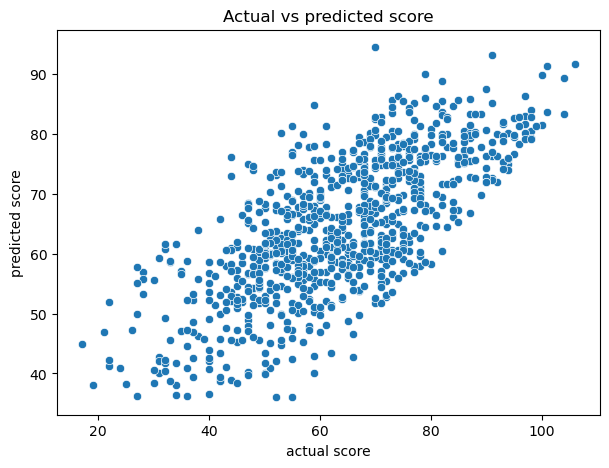

In [100]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("actual score")
plt.ylabel("predicted score")
plt.title("Actual vs predicted score")
plt.show()


In [102]:
если я пидор:
    выеби меня

SyntaxError: invalid syntax (3835574636.py, line 1)